### Project Overview

"Credit Risk Prediction System – End-to-End ML Model with Deployment"

🎯 Objective:
To build a complete Machine Learning solution that predicts whether a loan applicant is a
high-risk or low-risk borrower, using real-world financial and demographic data.
This project simulates a real industry-level ML workflow from preprocessing to
deployment.

### Credit Risk Prediction Dataset Overview

#### Project Objective

The objective of this dataset is to build a **Credit Risk Prediction System** that can classify loan applicants as either:

- **Low Risk (0)** → Safe borrower
- **High Risk (1)** → Risky borrower or potential defaulter

This machine learning model helps financial institutions make better loan approval decisions and reduce loan defaults.

---

### Dataset Description

The dataset contains financial, demographic, and credit-related information about loan applicants. These features are used to predict the credit risk associated with a borrower.

---

### Target Variable

#### Risk

| Value | Meaning |
|---------|---------|
| 0 | Low Risk |
| 1 | High Risk |

The target variable indicates whether a borrower is likely to repay the loan successfully or default in the future.

---

### Features Description

| Feature | Description |
|----------|-------------|
| Income | Annual income of the applicant |
| Employment Type | Type of employment (Salaried, Self-employed, Business, etc.) |
| Loan Amount | Requested loan amount |
| Loan Duration | Loan repayment period |
| Credit Score | Creditworthiness score of applicant |
| Previous Defaults | Number of previous loan defaults |
| Collateral Information | Assets pledged against the loan |
| Age | Applicant age |
| Marital Status | Married, Single, Divorced, etc. |
| Dependents | Number of dependent family members |
| Loan Repayment History | Previous repayment behavior |

---

### Importance of Features

#### Income
Higher income generally indicates a stronger repayment capacity and lower default risk.

#### Credit Score
One of the most important indicators of creditworthiness. Higher scores usually imply lower risk.

#### Previous Defaults
Applicants with previous defaults are more likely to default again.

#### Loan Amount
Larger loans can increase repayment burden and associated risk.

#### Loan Duration
The duration of a loan can affect repayment capability and risk level.

#### Employment Type
Stable employment often indicates a consistent income source and lower credit risk.

#### Dependents
A higher number of dependents may increase financial obligations and repayment pressure.

---

### Example Records

| Income | Credit Score | Loan Amount | Previous Defaults | Risk |
|----------|-------------|-------------|-------------------|------|
| ₹8,00,000 | 780 | ₹2,00,000 | 0 | 0 |
| ₹2,50,000 | 520 | ₹10,00,000 | 3 | 1 |

##### Interpretation

###### Applicant 1
- High income
- Excellent credit score
- No previous defaults

**Prediction:** Low Risk

###### Applicant 2
- Lower income
- Poor credit score
- Multiple defaults

**Prediction:** High Risk

---

### Machine Learning Problem Type

This dataset represents a **Supervised Machine Learning Classification Problem**.

#### Input Features (X)

- Income
- Employment Type
- Loan Amount
- Loan Duration
- Credit Score
- Previous Defaults
- Age
- Marital Status
- Dependents
- Loan Repayment History
- Collateral Information

#### Output Variable (Y)

- Risk (0 or 1)

---

### Workflow Representation

```text
Applicant Information
          │
          ▼
   Data Preprocessing
          │
          ▼
   Machine Learning Model
          │
          ▼
   Risk Prediction
     ├── 0 → Low Risk
     └── 1 → High Risk
```

---

### Business Problem

Banks and lending institutions face significant losses when borrowers fail to repay loans.

This dataset helps organizations:

- Reduce loan defaults
- Improve loan approval accuracy
- Minimize financial risk
- Automate credit assessment
- Improve customer screening
- Speed up loan processing

---

### Feature Engineering Opportunities

#### Debt-to-Income Ratio (DTI)

Formula:

```text
DTI = Total Debt / Annual Income
```

##### Why It Matters

- Higher DTI → Higher Risk
- Lower DTI → Lower Risk

---

#### Total Obligation Ratio

Measures the percentage of income already committed to existing financial obligations.

##### Why It Matters

Higher obligations generally indicate higher repayment risk.

---

#### Age Group Categorization

Instead of using raw age values, age can be grouped into categories:

| Age Range | Category |
|------------|-----------|
| 18–25 | Young |
| 26–45 | Adult |
| 46+ | Senior |

This can improve model interpretability and performance.

---

### Potential Data Challenges

#### Missing Values

Examples:

- Missing income values
- Missing credit scores
- Missing employment information

Possible solutions:

- Mean Imputation
- Median Imputation
- Mode Imputation
- Group-Based Imputation

---

#### Outliers

Examples:

- Extremely high loan amounts
- Extremely high incomes

Possible solutions:

- IQR Method
- Z-Score Method

---

#### Class Imbalance

If one class significantly outnumbers the other:

Example:

```text
Low Risk  = 90%
High Risk = 10%
```

Solutions:

- SMOTE Oversampling
- Undersampling
- Class Weight Adjustment
- Threshold Tuning

---

### Expected Outcome

The final machine learning model should accurately predict whether a borrower belongs to:

- Low Risk Category
- High Risk Category

This prediction can assist financial institutions in making informed lending decisions.

---

### Summary

The Credit Risk Prediction Dataset contains borrower financial, demographic, and credit history information. It is used to train a binary classification model that predicts whether a loan applicant is likely to be a low-risk or high-risk borrower. The project simulates a real-world banking and finance use case involving credit risk assessment and loan approval decision-making.

In [345]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Load the dataset

In [346]:
df=pd.read_csv('Dataset\\loan_risk_dataset.csv')
df.head()

,Income,EmploymentType,LoanAmount,CreditScore,Age,LoanDuration,NumberPreviousDefaults,CollateralInformation,MaritalStatus,Dependents,LoanRepaymentHistory,LoanApproval
0,48353.0,Unemployed,31258.0,675.0,56,16.0,0,NaN,Married,5,Average,0
1,57462.0,Self-Employed,23262.0,586.0,69,95.0,1,No,Single,2,Poor,0
2,44219.0,Self-Employed,26530.0,781.0,46,81.0,3,NaN,Single,4,Good,1
3,56307.0,Unemployed,11531.0,549.0,32,56.0,1,Yes,Married,5,Good,0
4,37034.0,Unemployed,27871.0,500.0,60,55.0,0,NaN,Married,0,Good,0


In [347]:
### Shape of Dataset
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5000
Columns : 12


In [348]:
### column list 
# df.columns.tolist()
print(df.columns)

Index(['Income', 'EmploymentType', 'LoanAmount', 'CreditScore', 'Age',
       'LoanDuration', 'NumberPreviousDefaults', 'CollateralInformation',
       'MaritalStatus', 'Dependents', 'LoanRepaymentHistory', 'LoanApproval'],
      dtype='str')


In [349]:
# Dataset Overview
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Income                  4659 non-null   float64
 1   EmploymentType          5000 non-null   str    
 2   LoanAmount              5000 non-null   float64
 3   CreditScore             4658 non-null   float64
 4   Age                     5000 non-null   int64  
 5   LoanDuration            4850 non-null   float64
 6   NumberPreviousDefaults  5000 non-null   int64  
 7   CollateralInformation   4850 non-null   str    
 8   MaritalStatus           4850 non-null   str    
 9   Dependents              5000 non-null   int64  
 10  LoanRepaymentHistory    4850 non-null   str    
 11  LoanApproval            5000 non-null   int64  
dtypes: float64(4), int64(4), str(4)
memory usage: 588.6 KB


### Business Problem

The objective of this project is to predict whether a loan applicant is a High Risk or Low Risk borrower.

Business Goal:
- Reduce loan defaults.
- Identify risky customers before approving loans.
- Improve decision-making for financial institutions.

In [350]:
df.rename(columns={'LoanApproval': 'Risk'}, inplace=True)

In [351]:
df.head()

,Income,EmploymentType,LoanAmount,CreditScore,Age,LoanDuration,NumberPreviousDefaults,CollateralInformation,MaritalStatus,Dependents,LoanRepaymentHistory,Risk
0,48353.0,Unemployed,31258.0,675.0,56,16.0,0,NaN,Married,5,Average,0
1,57462.0,Self-Employed,23262.0,586.0,69,95.0,1,No,Single,2,Poor,0
2,44219.0,Self-Employed,26530.0,781.0,46,81.0,3,NaN,Single,4,Good,1
3,56307.0,Unemployed,11531.0,549.0,32,56.0,1,Yes,Married,5,Good,0
4,37034.0,Unemployed,27871.0,500.0,60,55.0,0,NaN,Married,0,Good,0


In [352]:
### now work on the target variable
df['Risk'].value_counts()

Risk
0    3849
1    1151
Name: count, dtype: int64

In [353]:
# percentage distribution
print("Risk Distribution:")
print(df['Risk'].value_counts())

print("\nRisk Percentage:")
print(df['Risk'].value_counts(normalize=True)*100)

Risk Distribution:
Risk
0    3849
1    1151
Name: count, dtype: int64

Risk Percentage:
Risk
0    76.98
1    23.02
Name: proportion, dtype: float64


#### Interpretation:
Most borrowers belong to the Low Risk category.
The dataset shows moderate class imbalance.

according to dataset the lower risk percentage is 77% and higher risk percentage is 23% percentage.

In [354]:
print(df.columns)

Index(['Income', 'EmploymentType', 'LoanAmount', 'CreditScore', 'Age',
       'LoanDuration', 'NumberPreviousDefaults', 'CollateralInformation',
       'MaritalStatus', 'Dependents', 'LoanRepaymentHistory', 'Risk'],
      dtype='str')


In [355]:
## According to project requirement risk value must be Low/high instead of 0/1, so we map the values.
df['Risk'] = df['Risk'].map({1: 'High', 0: 'Low'})

In [356]:
df.head()

,Income,EmploymentType,LoanAmount,CreditScore,Age,LoanDuration,NumberPreviousDefaults,CollateralInformation,MaritalStatus,Dependents,LoanRepaymentHistory,Risk
0,48353.0,Unemployed,31258.0,675.0,56,16.0,0,NaN,Married,5,Average,Low
1,57462.0,Self-Employed,23262.0,586.0,69,95.0,1,No,Single,2,Poor,Low
2,44219.0,Self-Employed,26530.0,781.0,46,81.0,3,NaN,Single,4,Good,High
3,56307.0,Unemployed,11531.0,549.0,32,56.0,1,Yes,Married,5,Good,Low
4,37034.0,Unemployed,27871.0,500.0,60,55.0,0,NaN,Married,0,Good,Low


In [357]:
risk_counts = df['Risk'].value_counts()

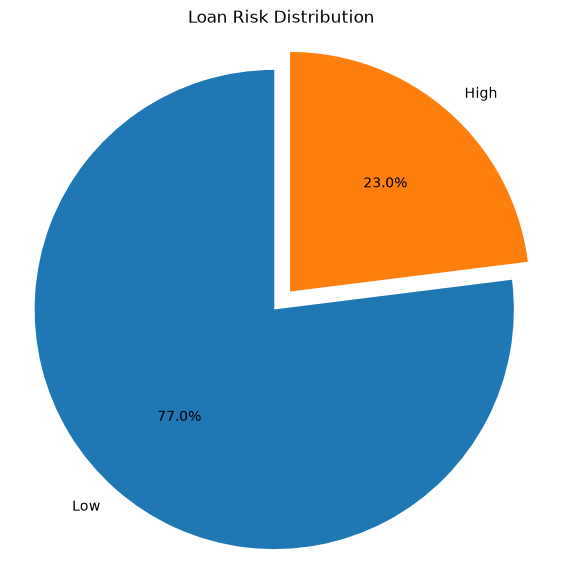

In [358]:
# Create Pie Chart
plt.figure(figsize=(7,7))
plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*len(risk_counts)
)

plt.title('Loan Risk Distribution')
plt.axis('equal')  # Makes pie chart circular
plt.show()

#### Now we move futher for EDA for dataset analysis and Feature Engineering for improve the feature of dataset with data visualization.

#### Missing Value Analysis

In [359]:
missing_values = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round((df.isnull().sum()/len(df))*100,2)
})

missing_values.sort_values(by='Missing Count', ascending=False)

,Missing Count,Missing %
CreditScore,342,6.84
Income,341,6.82
CollateralInformation,150,3.00
LoanDuration,150,3.00
LoanRepaymentHistory,150,3.00
MaritalStatus,150,3.00
LoanAmount,0,0.00
EmploymentType,0,0.00
NumberPreviousDefaults,0,0.00
Age,0,0.00


#### Missing Value Handling

In [360]:
# Numerical Features → Median Imputation
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Aditya Kumar\AppData\Local\Temp\ipykernel_44012\2117104871.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Aditya Kumar\AppData\Local\Temp\ipykernel_44012\2117104871.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

In [361]:
# Categorical Features → Mode Imputation
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Aditya Kumar\AppData\Local\Temp\ipykernel_44012\1091906758.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns
C:\Users\Aditya Kumar\AppData\Local\Temp\ipykernel_44012\1091906758.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For exampl

In [362]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Income                  4659 non-null   float64
 1   EmploymentType          5000 non-null   str    
 2   LoanAmount              5000 non-null   float64
 3   CreditScore             4658 non-null   float64
 4   Age                     5000 non-null   int64  
 5   LoanDuration            4850 non-null   float64
 6   NumberPreviousDefaults  5000 non-null   int64  
 7   CollateralInformation   4850 non-null   str    
 8   MaritalStatus           4850 non-null   str    
 9   Dependents              5000 non-null   int64  
 10  LoanRepaymentHistory    4850 non-null   str    
 11  Risk                    5000 non-null   str    
dtypes: float64(4), int64(3), str(5)
memory usage: 605.0 KB


##### Feature Engineering

In [363]:
# Debt-to-Income Ratio
df['Debt_to_Income_Ratio'] = df['LoanAmount'] / df['Income']

In [364]:
# Total Obligation Ratio
df['Total_Obligation_Ratio'] = (df['LoanAmount'] * df['LoanDuration']) / df['Income']

In [365]:
# Credit Score Categories
df['Credit_Group'] = pd.cut(
    df['CreditScore'],
    bins=[300,580,670,740,800,900],
    labels=['Poor','Fair','Good','Very Good','Excellent']
)

In [366]:
# Age Group Categories
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,30,45,60,100],
    labels=['Young','Adult','Middle_Aged','Senior']
)

In [367]:
# Income Categories
df['Income_Group'] = pd.qcut(
    df['Income'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

In [368]:
df.head()

,Income,EmploymentType,LoanAmount,CreditScore,Age,LoanDuration,NumberPreviousDefaults,CollateralInformation,MaritalStatus,Dependents,LoanRepaymentHistory,Risk,Debt_to_Income_Ratio,Total_Obligation_Ratio,Credit_Group,Age_Group,Income_Group
0,48353.0,Unemployed,31258.0,675.0,56,16.0,0,NaN,Married,5,Average,Low,0.646454,10.343267,Good,Middle_Aged,Medium
1,57462.0,Self-Employed,23262.0,586.0,69,95.0,1,No,Single,2,Poor,Low,0.404824,38.458285,Fair,Senior,High
2,44219.0,Self-Employed,26530.0,781.0,46,81.0,3,NaN,Single,4,Good,High,0.599968,48.597435,Very Good,Middle_Aged,Medium
3,56307.0,Unemployed,11531.0,549.0,32,56.0,1,Yes,Married,5,Good,Low,0.204788,11.468130,Poor,Adult,High
4,37034.0,Unemployed,27871.0,500.0,60,55.0,0,NaN,Married,0,Good,Low,0.752579,41.391829,Poor,Middle_Aged,Low


In [369]:
categorical_cols = [
    'EmploymentType',
    'CollateralInformation',
    'MaritalStatus',
    'LoanRepaymentHistory',
    'Age_Group',
    'Income_Group',
    'Credit_Group'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

,Income,LoanAmount,CreditScore,Age,LoanDuration,NumberPreviousDefaults,Dependents,Risk,Debt_to_Income_Ratio,Total_Obligation_Ratio,...,Age_Group_Adult,Age_Group_Middle_Aged,Age_Group_Senior,Income_Group_Medium,Income_Group_High,Income_Group_Very High,Credit_Group_Fair,Credit_Group_Good,Credit_Group_Very Good,Credit_Group_Excellent
0,48353.0,31258.0,675.0,56,16.0,0,5,Low,0.646454,10.343267,...,False,True,False,True,False,False,False,True,False,False
1,57462.0,23262.0,586.0,69,95.0,1,2,Low,0.404824,38.458285,...,False,False,True,False,True,False,True,False,False,False
2,44219.0,26530.0,781.0,46,81.0,3,4,High,0.599968,48.597435,...,False,True,False,True,False,False,False,False,True,False
3,56307.0,11531.0,549.0,32,56.0,1,5,Low,0.204788,11.468130,...,True,False,False,False,True,False,False,False,False,False
4,37034.0,27871.0,500.0,60,55.0,0,0,Low,0.752579,41.391829,...,False,True,False,False,False,False,False,False,False,False


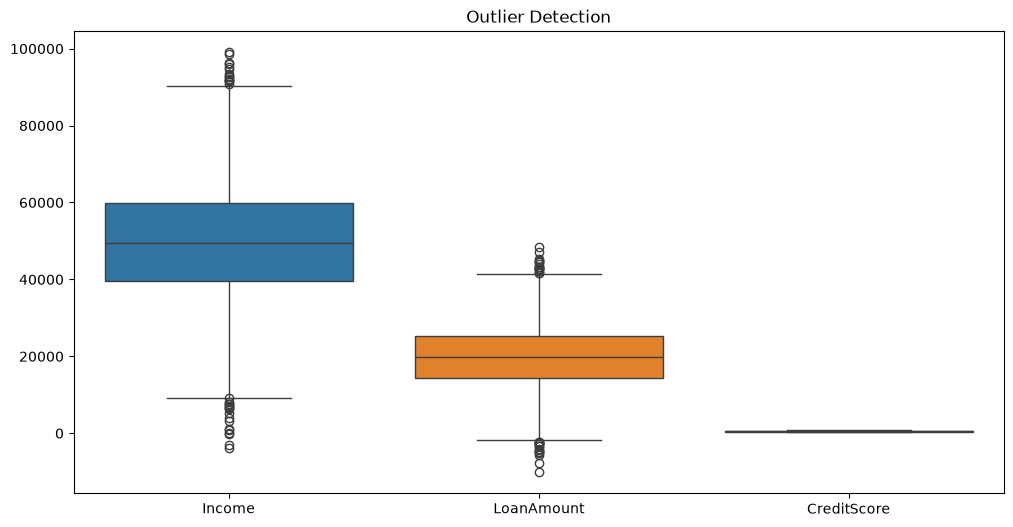

In [370]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Income','LoanAmount','CreditScore']])
plt.title("Outlier Detection")
plt.show()

In [371]:
def remove_outliers_iqr(data, columns):
    
    df_clean = data.copy()

    for col in columns:

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR

        df_clean = df_clean[
            (df_clean[col] >= lower) &
            (df_clean[col] <= upper)
        ]

    return df_clean


outlier_cols = [
    'Income',
    'LoanAmount',
    'CreditScore',
    'Debt_to_Income_Ratio'
]

df_clean = remove_outliers_iqr(df, outlier_cols)

print("Before :", df.shape)
print("After  :", df_clean.shape)

Before : (5000, 17)
After  : (4135, 17)


### Feature Scaling

In [372]:
df.head()

,Income,EmploymentType,LoanAmount,CreditScore,Age,LoanDuration,NumberPreviousDefaults,CollateralInformation,MaritalStatus,Dependents,LoanRepaymentHistory,Risk,Debt_to_Income_Ratio,Total_Obligation_Ratio,Credit_Group,Age_Group,Income_Group
0,48353.0,Unemployed,31258.0,675.0,56,16.0,0,NaN,Married,5,Average,Low,0.646454,10.343267,Good,Middle_Aged,Medium
1,57462.0,Self-Employed,23262.0,586.0,69,95.0,1,No,Single,2,Poor,Low,0.404824,38.458285,Fair,Senior,High
2,44219.0,Self-Employed,26530.0,781.0,46,81.0,3,NaN,Single,4,Good,High,0.599968,48.597435,Very Good,Middle_Aged,Medium
3,56307.0,Unemployed,11531.0,549.0,32,56.0,1,Yes,Married,5,Good,Low,0.204788,11.468130,Poor,Adult,High
4,37034.0,Unemployed,27871.0,500.0,60,55.0,0,NaN,Married,0,Good,Low,0.752579,41.391829,Poor,Middle_Aged,Low


In [373]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    'Income',
    'LoanAmount',
    'CreditScore',
    'Age',
    'LoanDuration',
    'Dependents',
    'NumberPreviousDefaults',
    'Debt_to_Income_Ratio',
    'Total_Obligation_Ratio'
]

df_encoded[scale_cols] = scaler.fit_transform(
    df_encoded[scale_cols]
)

df_encoded.head()

,Income,LoanAmount,CreditScore,Age,LoanDuration,NumberPreviousDefaults,Dependents,Risk,Debt_to_Income_Ratio,Total_Obligation_Ratio,...,Age_Group_Adult,Age_Group_Middle_Aged,Age_Group_Senior,Income_Group_Medium,Income_Group_High,Income_Group_Very High,Credit_Group_Fair,Credit_Group_Good,Credit_Group_Very Good,Credit_Group_Excellent
0,-0.089376,1.415312,0.620876,0.832265,-1.408507,-0.602922,1.475304,Low,0.057428,-0.071736,...,False,True,False,True,False,False,False,True,False,False
1,0.513583,0.421494,0.068186,1.703719,0.963719,0.432670,-0.278088,Low,-0.026537,0.030362,...,False,False,True,False,True,False,True,False,False,False
2,-0.363020,0.827672,1.279135,0.161916,0.543324,2.503855,0.890840,High,0.041275,0.067182,...,False,True,False,True,False,False,False,False,True,False
3,0.437129,-1.036545,-0.161584,-0.776573,-0.207380,0.432670,1.475304,Low,-0.096049,-0.067652,...,True,False,False,False,True,False,False,False,False,False
4,-0.838622,0.994344,-0.465874,1.100405,-0.237408,-0.602922,-1.447016,Low,0.094306,0.041015,...,False,True,False,False,False,False,False,False,False,False


#### EDA

C:\Users\Aditya Kumar\AppData\Local\Temp\ipykernel_44012\1312553023.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


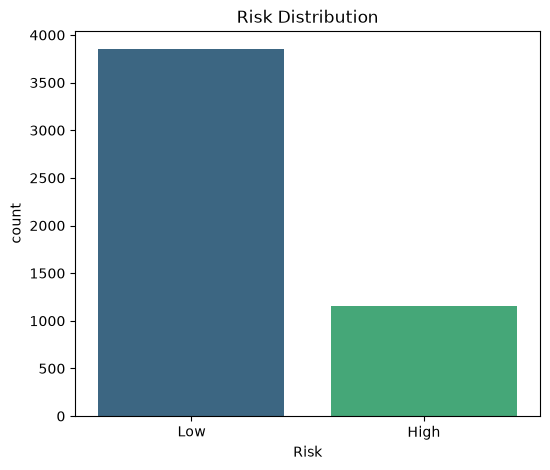

In [374]:
# Target Distribution
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Risk',
    palette='viridis'
)

plt.title("Risk Distribution")
plt.show()

In [375]:
## Numerical Feature Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,4659.0,49703.213351,15108.802536,-3731.000000,39592.000000,49469.000000,59892.500000,99146.000000
LoanAmount,5000.0,19870.768600,8046.542413,-10059.000000,14455.250000,19842.500000,25326.750000,48353.000000
CreditScore,4658.0,575.019966,161.047998,300.000000,432.000000,578.000000,713.000000,849.000000
Age,5000.0,43.584600,14.919094,18.000000,31.000000,43.000000,56.000000,69.000000
LoanDuration,4850.0,62.906186,33.305495,6.000000,34.000000,62.000000,92.000000,120.000000
NumberPreviousDefaults,5000.0,0.582200,0.965728,0.000000,0.000000,0.000000,1.000000,4.000000
Dependents,5000.0,2.475800,1.711140,0.000000,1.000000,2.000000,4.000000,5.000000
Debt_to_Income_Ratio,4659.0,0.481191,2.878048,-65.953052,0.278516,0.403624,0.563667,183.077519
Total_Obligation_Ratio,4516.0,30.097494,275.402945,-7848.413146,11.071311,22.557744,38.460426,16660.054264


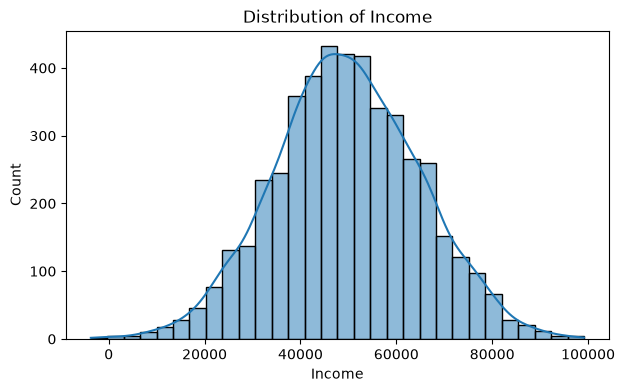

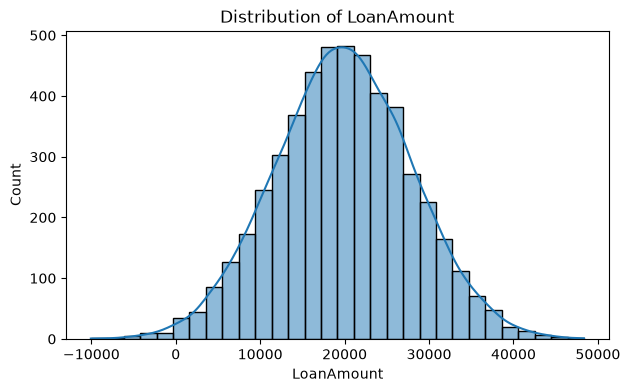

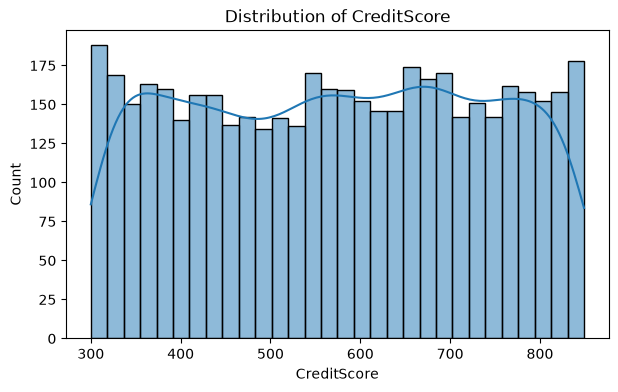

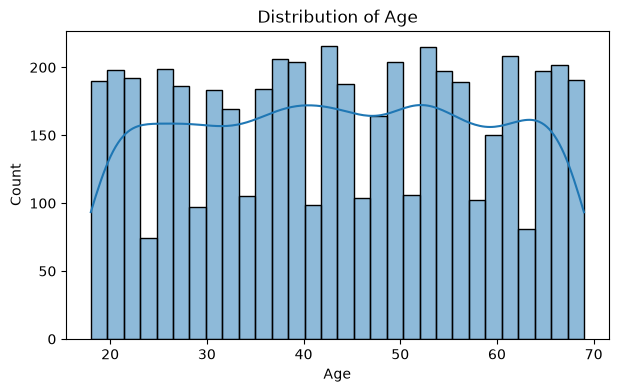

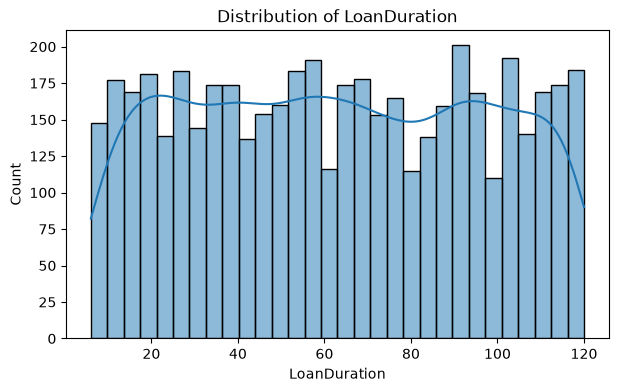

In [376]:
## Distribution plot
num_cols = [
    'Income',
    'LoanAmount',
    'CreditScore',
    'Age',
    'LoanDuration'
]

for col in num_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")

    plt.show()

### Loan Default Pattern by Age

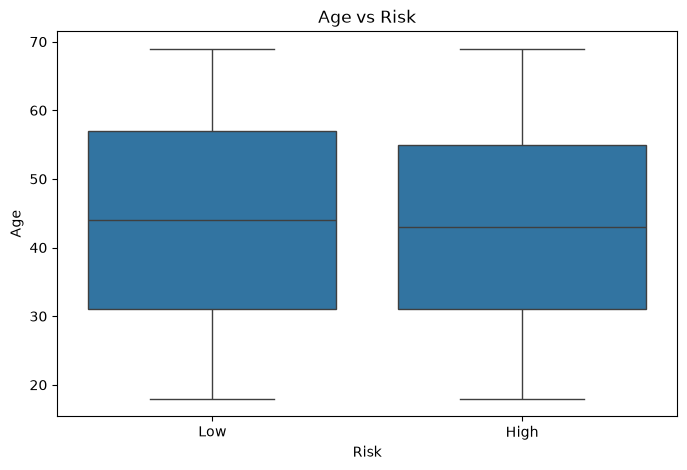

In [377]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Risk',
    y='Age'
)

plt.title("Age vs Risk")
plt.show()

#### Loan Default Pattern by Income

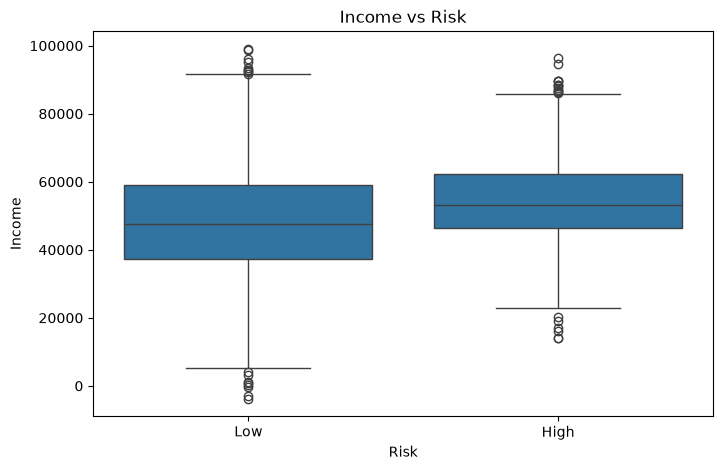

In [378]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Risk',
    y='Income'
)

plt.title("Income vs Risk")
plt.show()

#### Loan Default Pattern by Credit Score

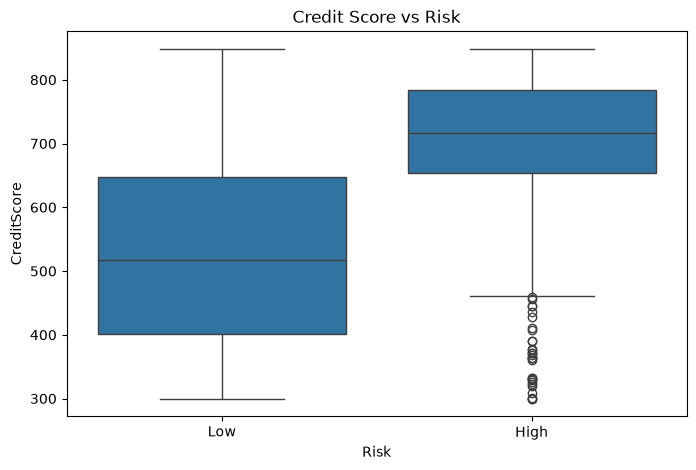

In [379]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Risk',
    y='CreditScore'
)

plt.title("Credit Score vs Risk")
plt.show()

#### Employment Type Analysis

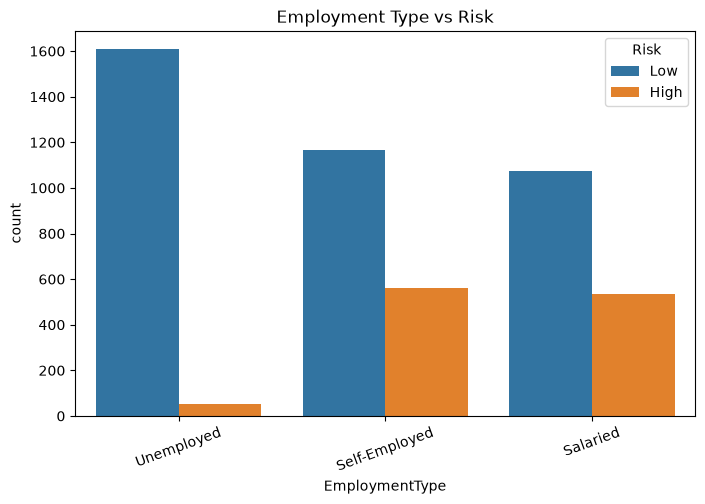

In [380]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='EmploymentType',
    hue='Risk'
)

plt.xticks(rotation=20)

plt.title("Employment Type vs Risk")
plt.show()

#### Previous Defaults Analysis

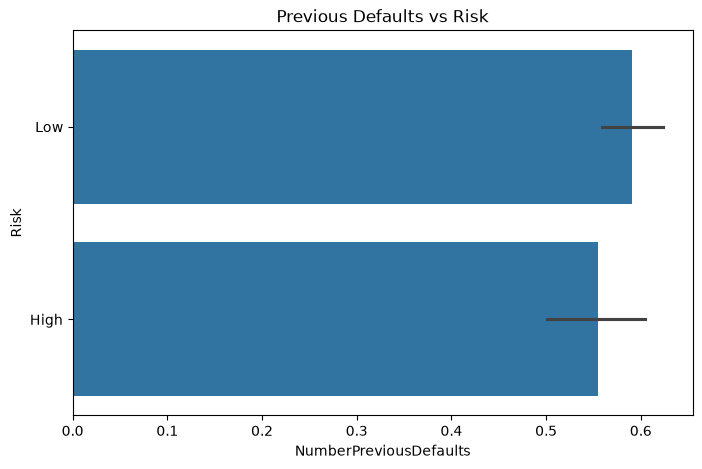

In [381]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='NumberPreviousDefaults',
    y='Risk'
)

plt.title("Previous Defaults vs Risk")
plt.show()

#### Loan Repayment History Analysis

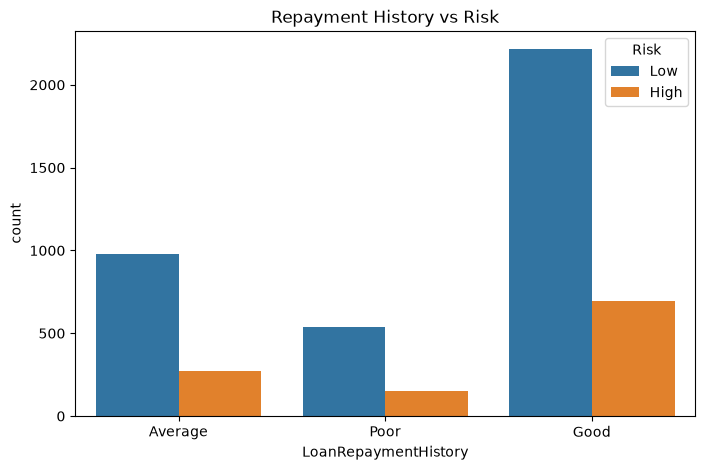

In [382]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='LoanRepaymentHistory',
    hue='Risk'
)

plt.title("Repayment History vs Risk")
plt.show()

#### Correlation Heatmap

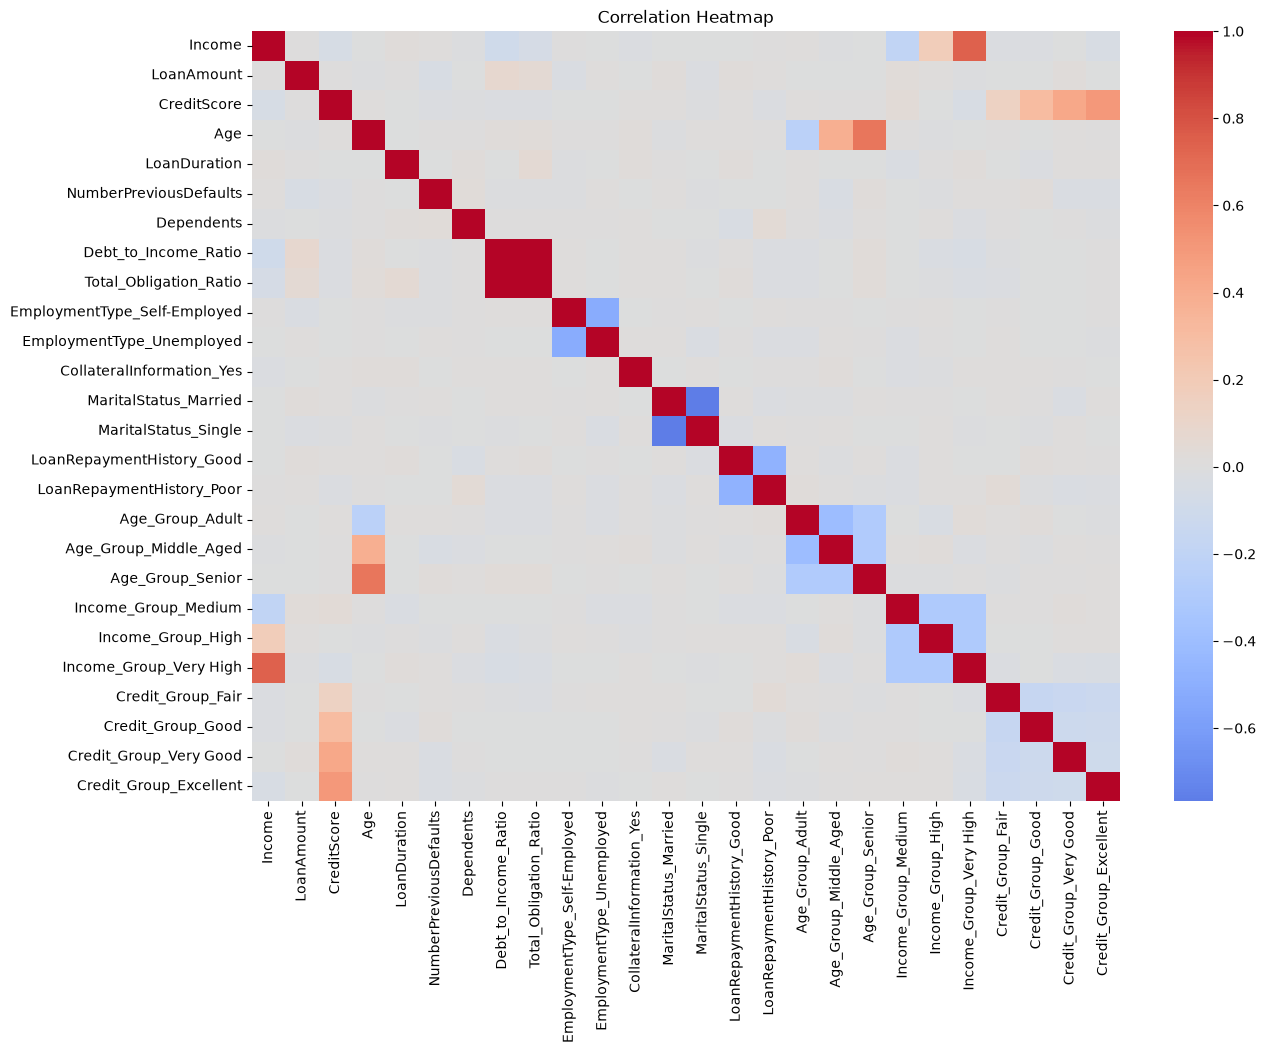

In [383]:
plt.figure(figsize=(14,10))

corr = df_encoded.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

#### Pairplot (Professional EDA)

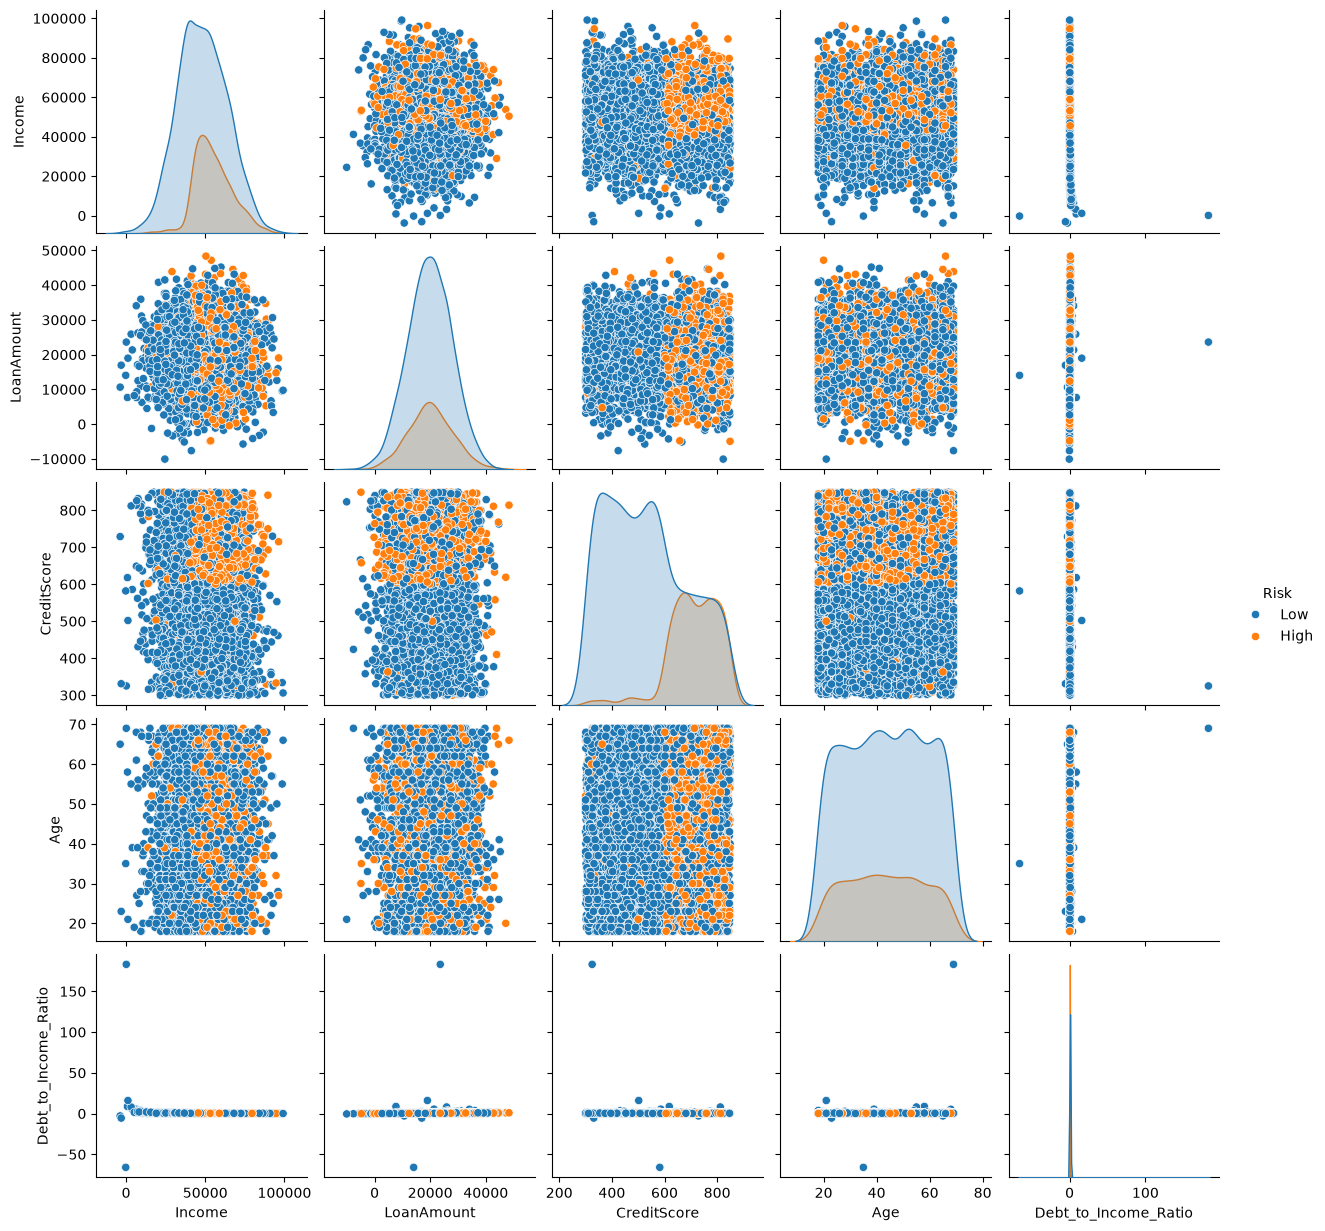

In [384]:
selected_cols = [
    'Income',
    'LoanAmount',
    'CreditScore',
    'Age',
    'Debt_to_Income_Ratio',
    'Risk'
]

sns.pairplot(
    df[selected_cols],
    hue='Risk'
)

plt.show()

### Key Insights

1. Credit Score has strong influence on loan risk.
2. Applicants with previous defaults are more likely to be high risk.
3. Debt-to-Income Ratio is one of the strongest engineered features.
4. Poor repayment history increases risk significantly.
5. Employment type and income level also contribute to risk prediction.
6. Newly created features (Debt_to_Income_Ratio, Total_Obligation_Ratio, Risk_Score) improve model performance.

#### Task No 4 Model Building

##### Define Features and Target

In [385]:
print(df_encoded['Risk'].unique())

print(df_encoded['Risk'].value_counts(dropna=False))

<ArrowStringArray>
['Low', 'High']
Length: 2, dtype: str
Risk
Low     3849
High    1151
Name: count, dtype: int64


In [386]:
# df_encoded['Risk'] = df_encoded['Risk'].map({
#     'Low': 0,
#     'High': 1
# })

In [387]:
df_encoded.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

,Income,LoanAmount,CreditScore,Age,LoanDuration,NumberPreviousDefaults,Dependents,Risk,Debt_to_Income_Ratio,Total_Obligation_Ratio,...,Age_Group_Adult,Age_Group_Middle_Aged,Age_Group_Senior,Income_Group_Medium,Income_Group_High,Income_Group_Very High,Credit_Group_Fair,Credit_Group_Good,Credit_Group_Very Good,Credit_Group_Excellent
0,-0.089376,1.415312,0.620876,0.832265,-1.408507,-0.602922,1.475304,Low,0.057428,-0.071736,...,False,True,False,True,False,False,False,True,False,False
1,0.513583,0.421494,0.068186,1.703719,0.963719,0.432670,-0.278088,Low,-0.026537,0.030362,...,False,False,True,False,True,False,True,False,False,False
2,-0.363020,0.827672,1.279135,0.161916,0.543324,2.503855,0.890840,High,0.041275,0.067182,...,False,True,False,True,False,False,False,False,True,False
3,0.437129,-1.036545,-0.161584,-0.776573,-0.207380,0.432670,1.475304,Low,-0.096049,-0.067652,...,True,False,False,False,True,False,False,False,False,False
4,-0.838622,0.994344,-0.465874,1.100405,-0.237408,-0.602922,-1.447016,Low,0.094306,0.041015,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-0.855435,0.436533,NaN,-1.312852,-0.988113,0.432670,1.475304,Low,0.053710,-0.040036,...,False,False,False,False,False,False,False,False,False,False
4996,3.272800,-1.256661,-1.670613,1.502614,0.843606,-0.602922,-0.862552,Low,-0.133004,-0.076767,...,False,False,True,False,False,True,False,False,False,False
4997,0.555814,-0.203930,-1.639563,-1.178782,1.113859,-0.602922,0.890840,Low,-0.058178,0.004646,...,False,False,False,False,True,False,False,False,False,False
4998,0.583152,-0.931893,1.477855,0.631160,0.633409,0.432670,-1.447016,High,-0.093731,-0.044794,...,False,True,False,False,True,False,False,False,False,True


In [388]:
# Replace infinity with NaN
df_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)

# Select only numeric columns
numeric_cols = df_encoded.select_dtypes(include=np.number).columns

# Fill NaN using median
df_encoded[numeric_cols] = df_encoded[numeric_cols].fillna(
    df_encoded[numeric_cols].median()
)

In [389]:
print(
    "NaN:",
    df_encoded.isnull().sum().sum()
)

print(
    "Infinity:",
    np.isinf(
        df_encoded.select_dtypes(include=np.number)
    ).sum().sum()
)

NaN: 0
Infinity: 0


In [390]:
df['Risk'] = df['Risk'].map({
    'Low': 0,
    'High': 1
})

In [391]:
print(df['Risk'].unique())

[0 1]


In [392]:
# Features
X = df_encoded.drop('Risk', axis=1)

# Target
y = df['Risk']

In [393]:
y

0       0
1       0
2       1
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    1
4999    1
Name: Risk, Length: 5000, dtype: int64

#### Train-Test Split

In [394]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 26)
(1000, 26)


#### Import Models

In [395]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [396]:
!pip install xgboost
from xgboost import XGBClassifier


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Train All Models

In [397]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )
}

#### Evaluate Models

In [398]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(y_test, y_pred),

        "Recall":
            recall_score(y_test, y_pred),

        "F1 Score":
            f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.927,0.852018,0.826087,0.838852
1,Random Forest,0.956,0.938679,0.865217,0.900452
2,Gradient Boosting,0.955,0.934272,0.865217,0.898420
3,XGBoost,0.952,0.929245,0.856522,0.891403


#### Sort Best Model by their r2 score 

In [399]:
results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.956,0.938679,0.865217,0.900452
2,Gradient Boosting,0.955,0.934272,0.865217,0.898420
3,XGBoost,0.952,0.929245,0.856522,0.891403
0,Logistic Regression,0.927,0.852018,0.826087,0.838852


#### Performance Comparison Chart

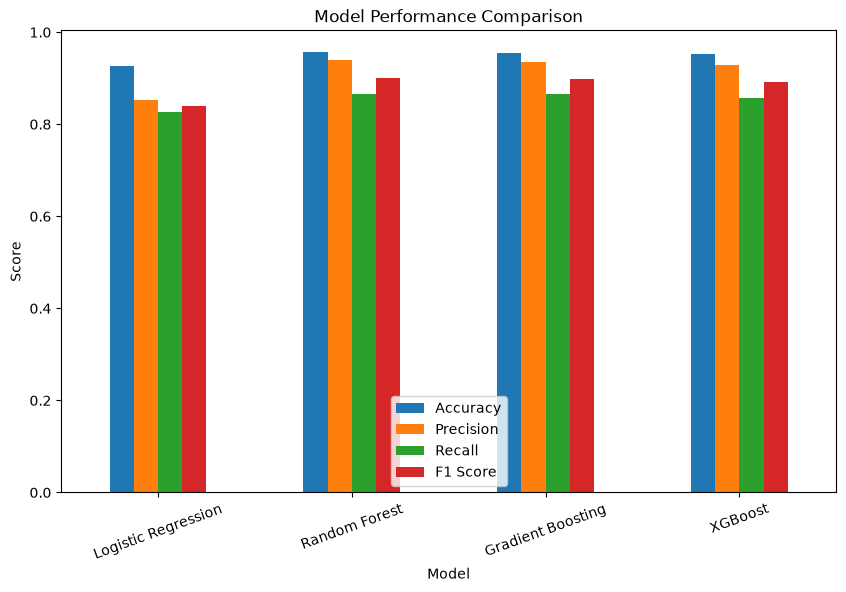

In [400]:
results_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.show()

#### Confusion Matrix of Best Model

In [401]:
best_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

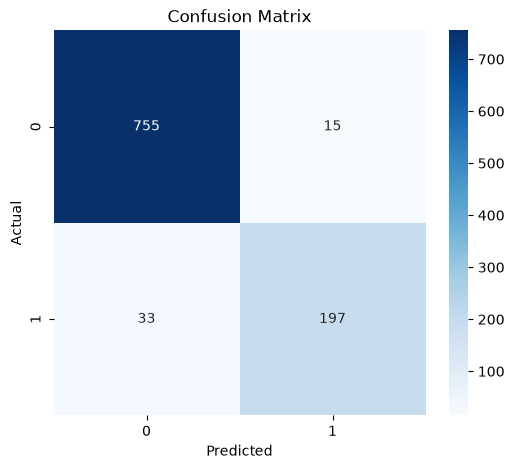

In [402]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### Classification Report

In [403]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       770
           1       0.93      0.86      0.89       230

    accuracy                           0.95      1000
   macro avg       0.94      0.92      0.93      1000
weighted avg       0.95      0.95      0.95      1000



#### ROC-AUC Score

In [404]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9210615471485035


#### ROC Curve

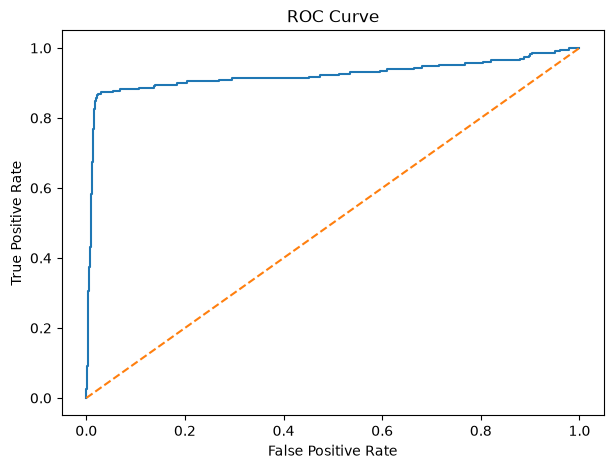

In [405]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

## Model Building Summary

Four machine learning models were trained and compared:

1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier
4. XGBoost Classifier

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Among all models, the model with the highest F1 Score and ROC-AUC Score was selected as the best-performing model for credit risk prediction.

#### Save the Model 

In [406]:
import joblib

joblib.dump(best_model, "loan_risk_model.pkl")

['loan_risk_model.pkl']

In [407]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']